In [1]:
import pandas as pd

pd.set_option('display.max_columns', 39)

dados = pd.read_csv('Customer-Churn.csv', delimiter = ',')
dados.head()

,Maior65Anos,Conjuge,Dependentes,MesesDeContrato,TelefoneFixo,VariasLinhasTelefonicas,ServicoDeInternet,SegurancaOnline,BackupOnline,SeguroNoDispositivo,SuporteTecnico,TVaCabo,StreamingDeFilmes,TipoDeContrato,PagamentoOnline,FormaDePagamento,ContaMensal,Churn
0,0,Sim,Nao,1,Nao,SemServicoTelefonico,DSL,Nao,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequeDigital,29.85,Nao
1,0,Nao,Nao,34,Sim,Nao,DSL,Sim,Nao,Sim,Nao,Nao,Nao,UmAno,Nao,ChequePapel,56.95,Nao
2,0,Nao,Nao,2,Sim,Nao,DSL,Sim,Sim,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequePapel,53.85,Sim
3,0,Nao,Nao,45,Nao,SemServicoTelefonico,DSL,Sim,Nao,Sim,Sim,Nao,Nao,UmAno,Nao,DebitoEmConta,42.30,Nao
4,0,Nao,Nao,2,Sim,Nao,FibraOptica,Nao,Nao,Nao,Nao,Nao,Nao,Mensalmente,Sim,ChequeDigital,70.70,Sim


In [2]:
dados.shape

(7043, 18)

In [3]:
# Modificação de forma manual

traducao_dic = {'Sim': 1, 
                'Nao': 0}

dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)
dadosmodificados.head()

/var/folders/zb/8yssb2s94676n1_h6sxcsn1h0000gn/T/ipykernel_4341/1753793938.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)


,Conjuge,Dependentes,TelefoneFixo,PagamentoOnline,Churn
0,1,0,0,1,0
1,0,0,1,0,0
2,0,0,1,1,1
3,0,0,0,0,0
4,0,0,1,1,1


In [4]:
# Transformação pelo get_dummyes

dummie_dados = pd.get_dummies(dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'], axis = 1))

dummie_dados = pd.get_dummies(dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'],
                axis=1))

#junção dos dados trasformados com os que já tinhamos
dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)


In [5]:
dados_final.head()

,Conjuge,Dependentes,TelefoneFixo,PagamentoOnline,Churn,Maior65Anos,MesesDeContrato,ContaMensal,VariasLinhasTelefonicas_Nao,VariasLinhasTelefonicas_SemServicoTelefonico,VariasLinhasTelefonicas_Sim,ServicoDeInternet_DSL,ServicoDeInternet_FibraOptica,ServicoDeInternet_Nao,SegurancaOnline_Nao,SegurancaOnline_SemServicoDeInternet,SegurancaOnline_Sim,BackupOnline_Nao,BackupOnline_SemServicoDeInternet,BackupOnline_Sim,SeguroNoDispositivo_Nao,SeguroNoDispositivo_SemServicoDeInternet,SeguroNoDispositivo_Sim,SuporteTecnico_Nao,SuporteTecnico_SemServicoDeInternet,SuporteTecnico_Sim,TVaCabo_Nao,TVaCabo_SemServicoDeInternet,TVaCabo_Sim,StreamingDeFilmes_Nao,StreamingDeFilmes_SemServicoDeInternet,StreamingDeFilmes_Sim,TipoDeContrato_DoisAnos,TipoDeContrato_Mensalmente,TipoDeContrato_UmAno,FormaDePagamento_CartaoDeCredito,FormaDePagamento_ChequeDigital,FormaDePagamento_ChequePapel,FormaDePagamento_DebitoEmConta
0,1,0,0,1,0,0,1,29.85,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False
1,0,0,1,0,0,0,34,56.95,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False
2,0,0,1,1,1,0,2,53.85,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,True,False
3,0,0,0,0,0,0,45,42.30,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False,True
4,0,0,1,1,1,0,2,70.70,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False


In [6]:
x_maria = [[0,0,1,1,0,0,39.90,1,0,0,0,1,0,1,0,0,0,0,1,1,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1]]

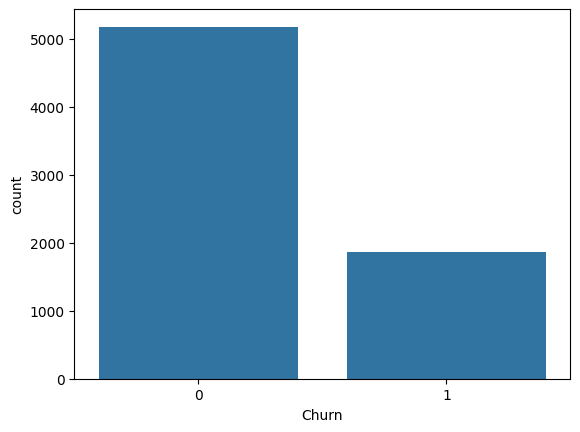

In [7]:
# Variável target está desbalanceada
import seaborn as sns
%matplotlib inline
ax = sns.countplot(x='Churn', data=dados_final)

In [8]:
dados_final.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
# Biblioteca para balancear os dados utilizando over_sampling
from imblearn.over_sampling import SMOTE

# Dividindo os dados em caracteristicas e target
X = dados_final.drop('Churn', axis = 1)
y = dados_final['Churn']

smt = SMOTE(random_state=123)
X, y = smt.fit_resample(X, y)


# Junção dos dados balanceados
dados_final = pd.concat([X, y], axis=1)

# Verificação 1 - junção dos dados
dados_final.head(2)

,Conjuge,Dependentes,TelefoneFixo,PagamentoOnline,Maior65Anos,MesesDeContrato,ContaMensal,VariasLinhasTelefonicas_Nao,VariasLinhasTelefonicas_SemServicoTelefonico,VariasLinhasTelefonicas_Sim,ServicoDeInternet_DSL,ServicoDeInternet_FibraOptica,ServicoDeInternet_Nao,SegurancaOnline_Nao,SegurancaOnline_SemServicoDeInternet,SegurancaOnline_Sim,BackupOnline_Nao,BackupOnline_SemServicoDeInternet,BackupOnline_Sim,SeguroNoDispositivo_Nao,SeguroNoDispositivo_SemServicoDeInternet,SeguroNoDispositivo_Sim,SuporteTecnico_Nao,SuporteTecnico_SemServicoDeInternet,SuporteTecnico_Sim,TVaCabo_Nao,TVaCabo_SemServicoDeInternet,TVaCabo_Sim,StreamingDeFilmes_Nao,StreamingDeFilmes_SemServicoDeInternet,StreamingDeFilmes_Sim,TipoDeContrato_DoisAnos,TipoDeContrato_Mensalmente,TipoDeContrato_UmAno,FormaDePagamento_CartaoDeCredito,FormaDePagamento_ChequeDigital,FormaDePagamento_ChequePapel,FormaDePagamento_DebitoEmConta,Churn
0,1,0,0,1,0,1,29.85,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,0
1,0,0,1,0,0,34,56.95,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,0


# Modelo K-Nearest Meighbors(KNN)

O KNN é um algoritmo baseado em instâncias que classifica um ponto de dados com base na proximidade dos pontos de dados de treinamento. Em outras palavras, ele faz previsões com base na similaridade entre os dados.

### Como funciona?
- Escolha do valor de K: O primeiro passo é escolher o número de vizinhos mais próximos (K). Este valor é crucial, pois um K muito pequeno pode levar a um modelo ruidoso, enquanto um K muito grande pode suavizar demais a fronteira de decisão.

- Cálculo da distância: Para cada ponto de dados no conjunto de teste, o KNN calcula a distância entre esse ponto e todos os pontos do conjunto de treinamento. As distâncias mais comuns usadas são a Euclidiana, Manhattan e Minkowski.

- Seleção dos K vizinhos mais próximos: Após calcular as distâncias, o algoritmo seleciona os K pontos de dados de treinamento mais próximos.

### Classificação ou regressão:

- **Classificação**: O rótulo da classe é determinado pela maioria dos rótulos dos K vizinhos mais próximos.

- **Regressão**: O valor é determinado pela média (ou mediana) dos valores dos K vizinhos mais próximos.

### Vantagens
- Simplicidade: Fácil de entender e implementar.
- Flexibilidade: Pode ser usado tanto para classificação quanto para regressão.
- Sem suposições: Não faz suposições sobre a distribuição dos dados.
### Desvantagens
- Custo computacional: Pode ser computacionalmente caro, especialmente com grandes conjuntos de dados, pois requer o cálculo da distância para todos os pontos de treinamento.
- Sensibilidade à escala dos dados: A performance pode ser afetada se os dados não forem normalizados.
- Escolha do K: A escolha do valor de K pode ser subjetiva e requer experimentação.


In [10]:
# Divisão em Inputs e Outputs

x = dados_final.drop('Churn', axis = 1)
y = dados_final['Churn']
y = y.astype('category')

In [11]:
# Padronizar os Dados

from sklearn.preprocessing import StandardScaler

norm = StandardScaler()

x_normalizado = norm.fit_transform(x)
x_normalizado

array([[ 1.26542767, -0.52756038, -3.06083934, ...,  1.05443669,
        -0.54712618, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ..., -0.94837368,
         1.82773194, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ..., -0.94837368,
         1.82773194, -0.5315994 ],
       ...,
       [-0.79024667, -0.52756038,  0.32670777, ...,  1.05443669,
        -0.54712618, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ..., -0.94837368,
        -0.54712618, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ..., -0.94837368,
        -0.54712618, -0.5315994 ]])

In [12]:
x_maria_normalizado = norm.transform(pd.DataFrame(x_maria, columns =  x.columns))
x_maria_normalizado

array([[-0.79024667, -0.52756038,  0.32670777,  0.81514931, -0.41254225,
        -1.14935017, -0.9723572 ,  1.00406703, -0.32670777, -0.93540224,
        -0.67423777,  0.94470379, -0.44850949,  0.77835396, -0.44850949,
        -0.59625062, -1.09729069, -0.44850949,  1.35149921,  0.91918014,
         2.22960721, -0.73976267, -1.27269275,  2.22960721, -0.60667885,
         1.08898545, -0.44850949, -0.84638695, -0.90389849, -0.44850949,
         1.16590099, -0.4605816 , -1.45333425,  2.11545084, -0.50820122,
        -0.94837368, -0.54712618,  1.88111576]])

In [13]:
# Distância Euclidiana

import numpy as np

a = x_maria_normalizado
b = x_normalizado[0]

In [14]:
a - b

array([[-2.05567434,  0.        ,  3.38754711,  0.        ,  0.        ,
        -0.04166352,  0.34941285,  2.00001647, -3.38754711,  0.        ,
        -2.15739408,  2.00323664,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         2.6781167 ,  0.        , -2.05842835,  2.6781167 ,  0.        ,
         0.        ,  0.        ,  0.        , -2.01021741,  0.        ,
         2.02360676,  0.        , -2.14140721,  2.58816332,  0.        ,
        -2.00281037,  0.        ,  2.41271515]])

In [15]:
np.square(a - b)

array([[4.22579699e+00, 0.00000000e+00, 1.14754754e+01, 0.00000000e+00,
        0.00000000e+00, 1.73584854e-03, 1.22089340e-01, 4.00006590e+00,
        1.14754754e+01, 0.00000000e+00, 4.65434920e+00, 4.01295706e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        7.17230906e+00, 0.00000000e+00, 4.23712727e+00, 7.17230906e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        4.04097403e+00, 0.00000000e+00, 4.09498430e+00, 0.00000000e+00,
        4.58562485e+00, 6.69858936e+00, 0.00000000e+00, 4.01124936e+00,
        0.00000000e+00, 5.82119441e+00]])

In [68]:
np.sqrt(np.sum(np.square(a - b)))

np.float64(9.169282435541762)

## Implementando Modelo K-Nearest Meighbors(KNN)

In [16]:
# Divisão dos dados em treino e teste

from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x_normalizado, y, test_size = 0.3, random_state = 123)

In [17]:
# Treino e Teste

# Biblioteca para criarmos o modelo de machine learning
from sklearn.neighbors import KNeighborsClassifier

# Instanciar o modelo (por padrão são 5 vizinhos)
KNN = KNeighborsClassifier(metric = 'euclidean')

# Treinando o o modelo com dados de treino
KNN.fit(x_treino, y_treino)

# Testando o modelo com os dados de teste
predito_KNN = KNN.predict(x_teste)


In [18]:
predito_KNN

array([1, 0, 0, ..., 0, 1, 1])

# Modelo Bernoulli Naïve Bayes

In [19]:
x_treino

array([[-0.79024667, -0.52756038, -3.06083934, ..., -0.94837368,
         1.82773194, -0.5315994 ],
       [ 1.26542767,  1.89551764,  0.32670777, ..., -0.94837368,
         1.82773194, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ...,  1.05443669,
        -0.54712618, -0.5315994 ],
       ...,
       [ 1.26542767,  1.89551764,  0.32670777, ..., -0.94837368,
         1.82773194, -0.5315994 ],
       [ 1.26542767,  1.89551764,  0.32670777, ...,  1.05443669,
        -0.54712618, -0.5315994 ],
       [-0.79024667, -0.52756038,  0.32670777, ...,  1.05443669,
        -0.54712618, -0.5315994 ]])

In [21]:
y_treino

4831    0
5077    0
9023    1
4424    1
5236    0
       ..
9785    1
7763    1
5218    0
1346    1
3582    0
Name: Churn, Length: 7243, dtype: category
Categories (2, int64): [0, 1]

In [22]:
np.median(x_treino)

np.float64(-0.44850949388572553)

In [25]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB(binarize = 0.44)
bnb.fit(x_treino, y_treino)
predito_Bnb = bnb.predict(x_teste)
predito_Bnb

array([1, 0, 0, ..., 1, 1, 1])

# Modelo Árvore de Decisão

In [26]:
from sklearn.tree import DecisionTreeClassifier

dct = DecisionTreeClassifier(criterion = 'entropy', random_state = 42)
dct.fit(x_treino, y_treino)
dct.feature_importances_

array([1.67524047e-02, 1.48476282e-02, 8.01742170e-04, 1.92954499e-02,
       1.64128159e-02, 1.53400898e-01, 2.03589807e-01, 8.45489222e-03,
       5.11300357e-03, 1.56797415e-02, 5.93521796e-03, 3.21703370e-03,
       0.00000000e+00, 5.35776860e-02, 0.00000000e+00, 1.65772991e-02,
       1.10714689e-02, 0.00000000e+00, 1.01911393e-02, 8.55382235e-03,
       0.00000000e+00, 1.14572757e-02, 1.42219337e-02, 0.00000000e+00,
       1.59463463e-02, 4.72104341e-03, 2.20429361e-04, 5.68756613e-03,
       7.77405311e-03, 0.00000000e+00, 1.89318675e-02, 8.93017215e-03,
       2.33489354e-01, 2.80406976e-02, 1.75959948e-02, 3.50938720e-02,
       1.23301553e-02, 2.20871885e-02])

In [28]:
predito_dct = dct.predict(x_teste)
predito_dct

array([0, 0, 0, ..., 0, 1, 1])

# Matriz de Confusão

In [30]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_teste, predito_KNN))
print(confusion_matrix(y_teste, predito_Bnb))
print(confusion_matrix(y_teste, predito_dct))

[[1246  323]
 [ 262 1274]]
[[1060  509]
 [ 209 1327]]
[[1273  296]
 [ 285 1251]]


# Acurácia

In [31]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_teste, predito_KNN))
print(accuracy_score(y_teste, predito_Bnb))
print(accuracy_score(y_teste, predito_dct))

0.8115942028985508
0.7687600644122383
0.8128824476650564


# Precisão

In [32]:
from sklearn.metrics import precision_score

print(precision_score(y_teste, predito_KNN))
print(precision_score(y_teste, predito_Bnb))
print(precision_score(y_teste, predito_dct))

0.7977457733249843
0.7227668845315904
0.8086619263089851


# Recall

In [33]:
from sklearn.metrics import recall_score

print(recall_score(y_teste, predito_KNN))
print(recall_score(y_teste, predito_Bnb))
print(recall_score(y_teste, predito_dct))

0.8294270833333334
0.8639322916666666
0.814453125
